# Sentiment Scoring — VADER & RoBERTa

**Project:** SPZ — Geographic Bias in Pre-Trained Sentiment Classifiers

**Author:** Rezvaneh Mousavi | JLU Giessen | M.Sc. Data Analytics

**Supervisor:** Prof. Dr. Stefan Hennemann

---

**Purpose of this notebook:**

Apply two pre-trained sentiment classifiers — VADER (lexicon-based) and RoBERTa (transformer-based) — to the lead paragraphs of all country-assigned articles. The resulting scores are the dependent variable in the geographic bias analysis.

**Why two classifiers:**

If both a lexicon-based and a transformer-based classifier show the same geographic pattern, the finding is robust — it cannot be attributed to the quirks of a single tool. This dual-classifier approach was validated in the previous semester project (Mousavi & Brandao da Silva, 2025).

**Scoring approach:**

- **VADER:** Compound score ranging from -1 (most negative) to +1 (most positive). Designed for social media text — known domain mismatch with formal news.
- **RoBERTa:** `cardiffnlp/twitter-roberta-base-sentiment-latest` returns probabilities for negative, neutral, and positive. We compute a pseudo-compound score = P(positive) - P(negative), ranging from -1 to +1, for direct comparison with VADER.

Both classifiers are applied to the **lead paragraph** (`lead_text`), not the full article, following the approach validated in the previous project.

**Input:** `articles_with_country_2025_01_v2.csv` (from Notebook 01)

**Output:** `articles_with_sentiment_2025_01_v2.csv`

---
## 0. Setup

In [1]:
!pip install -q vaderSentiment transformers torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 5.3 MB/s eta 0:00:00


In [2]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
from scipy import stats

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from transformers import pipeline

warnings.filterwarnings('ignore')
matplotlib.rcParams.update({'font.size': 11, 'figure.facecolor': 'white'})

print('All imports loaded successfully.')

All imports loaded successfully.


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# --- Paths (must match Notebook 01) ---
DRIVE_BASE = '/content/drive/MyDrive/UNI/JLU M.Sc Data Analytics/Semester 3/Spezialisierungmodule'
DATA_PROCESSED = f'{DRIVE_BASE}/data/processed'

TARGET_YEAR = '2025'
TARGET_MONTH = '01'
DATA_VERSION = 'v2'

# Input: output of Notebook 01
INPUT_PATH = f'{DATA_PROCESSED}/articles_with_country_{TARGET_YEAR}_{TARGET_MONTH}_{DATA_VERSION}.csv'

# Output: articles with sentiment scores added
OUTPUT_PATH = f'{DATA_PROCESSED}/articles_with_sentiment_{TARGET_YEAR}_{TARGET_MONTH}_{DATA_VERSION}.csv'

# Minimum articles per country to include in the analysis
MIN_ARTICLES_PER_COUNTRY = 50

assert os.path.exists(INPUT_PATH), f'Input file not found: {INPUT_PATH}'
print(f'Input:  {INPUT_PATH}')
print(f'Output: {OUTPUT_PATH}')

Input:  /content/drive/MyDrive/UNI/JLU M.Sc Data Analytics/Semester 3/Spezialisierungmodule/data/processed/articles_with_country_2025_01_v2.csv
Output: /content/drive/MyDrive/UNI/JLU M.Sc Data Analytics/Semester 3/Spezialisierungmodule/data/processed/articles_with_sentiment_2025_01_v2.csv


---
## 1. Load Data

In [5]:
df = pd.read_csv(INPUT_PATH)
print(f'Loaded {len(df)} articles')
print(f'With country assignment: {df["country_url"].notna().sum()}')
print(f'With lead text: {df["lead_text"].notna().sum()}')

# Filter to articles that have both a country and a usable lead
df_scored = df[df['country_url'].notna() & df['lead_text'].notna()].copy()
print(f'\nArticles for scoring (country + lead): {len(df_scored)}')

print(f'\nCountry distribution:')
print(df_scored['country_url'].value_counts().to_string())

Loaded 30378 articles
With country assignment: 9715
With lead text: 30378

Articles for scoring (country + lead): 9715

Country distribution:
country_url
IN    4903
US    2598
UK     458
AE     374
PK     265
NG     240
AU     115
MY      89
CN      87
DE      85
AT      82
IL      78
SG      61
ZA      56
QA      52
KE      43
ZM      43
TH      27
IR      27
KR      25
FJ       7


---
## 2. VADER Sentiment Scoring

VADER (Valence Aware Dictionary and sEntiment Reasoner) is a lexicon- and rule-based sentiment tool specifically designed for social media text (Hutto & Gilbert, 2014). It produces a compound score between -1 and +1 by summing the valence of each word and applying rules for negation, intensification, and punctuation.

**Known limitation for this study:** VADER was trained on social media, not formal news prose. This domain mismatch is part of what we are investigating — if VADER scores differ across countries, it may reflect differences in writing style rather than actual sentiment.

In [6]:
# === CHECKPOINT: VADER scores ===
if os.path.exists(OUTPUT_PATH):
    print(f'Checkpoint found: {OUTPUT_PATH}')
    df_scored = pd.read_csv(OUTPUT_PATH)
    print(f'Loaded {len(df_scored)} articles with sentiment scores.')
    vader_already_done = True
    roberta_already_done = True
else:
    vader_already_done = False
    roberta_already_done = False

if not vader_already_done:
    analyzer = SentimentIntensityAnalyzer()

    def vader_score(text):
        """Return VADER compound score for a text."""
        if pd.isna(text) or str(text).strip() == '':
            return 0.0
        return analyzer.polarity_scores(str(text))['compound']

    print(f'Running VADER on {len(df_scored)} lead paragraphs...')
    df_scored['vader_compound'] = df_scored['lead_text'].apply(vader_score)

    # Discrete labels using standard VADER thresholds
    df_scored['vader_label'] = df_scored['vader_compound'].apply(
        lambda x: 'positive' if x >= 0.05 else ('negative' if x <= -0.05 else 'neutral')
    )

    print(f'Done. VADER label distribution:')
    print(df_scored['vader_label'].value_counts().to_string())
    print(f'\nMean compound score: {df_scored["vader_compound"].mean():.4f}')
    print(f'Std:                 {df_scored["vader_compound"].std():.4f}')

Running VADER on 9715 lead paragraphs...
Done. VADER label distribution:
vader_label
positive    4934
negative    2899
neutral     1882

Mean compound score: 0.1369
Std:                 0.5590


---
## 3. RoBERTa Sentiment Scoring

The `cardiffnlp/twitter-roberta-base-sentiment-latest` model (Barbieri et al., 2020) is a RoBERTa model fine-tuned on ~124M tweets for three-class sentiment classification. Like VADER, it was trained on social media — applying it to formal news text intentionally exposes domain mismatch.

**Scoring:** The model outputs probabilities for negative, neutral, and positive. We compute:
- `roberta_compound` = P(positive) - P(negative), ranging from -1 to +1
- `roberta_label` = the class with the highest probability

The pseudo-compound score allows direct numerical comparison with VADER on the same scale.

**Note:** RoBERTa truncates input to 512 tokens. Lead paragraphs are typically well within this limit.

In [7]:
if not roberta_already_done:
    print('Loading RoBERTa model (this may take 1-2 minutes)...')
    roberta_classifier = pipeline(
        'sentiment-analysis',
        model='cardiffnlp/twitter-roberta-base-sentiment-latest',
        max_length=512,
        truncation=True,
        top_k=None  # return all 3 class probabilities
    )
    print('Model loaded.')

    def roberta_score(text):
        """
        Return (pseudo_compound, label) from RoBERTa.

        pseudo_compound = P(positive) - P(negative), range [-1, +1]
        label = class with highest probability
        """
        if pd.isna(text) or str(text).strip() == '':
            return 0.0, 'neutral'
        try:
            results = roberta_classifier(str(text)[:512])[0]
            # results is a list of dicts: [{'label': 'positive', 'score': 0.8}, ...]
            probs = {r['label'].lower(): r['score'] for r in results}

            p_pos = probs.get('positive', 0.0)
            p_neg = probs.get('negative', 0.0)
            p_neu = probs.get('neutral', 0.0)

            compound = p_pos - p_neg
            label = max(probs, key=probs.get)
            return compound, label
        except Exception:
            return 0.0, 'neutral'

    print(f'Running RoBERTa on {len(df_scored)} lead paragraphs...')
    print('(This takes approximately 5-15 minutes depending on GPU availability)\n')

    roberta_results = df_scored['lead_text'].apply(roberta_score)
    df_scored['roberta_compound'] = roberta_results.apply(lambda x: x[0])
    df_scored['roberta_label'] = roberta_results.apply(lambda x: x[1])

    print(f'Done. RoBERTa label distribution:')
    print(df_scored['roberta_label'].value_counts().to_string())
    print(f'\nMean pseudo-compound: {df_scored["roberta_compound"].mean():.4f}')
    print(f'Std:                  {df_scored["roberta_compound"].std():.4f}')

Loading RoBERTa model (this may take 1-2 minutes)...


config.json:   0%|          | 0.00/929 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/501M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 
roberta.pooler.dense.bias       | UNEXPECTED |  | 
roberta.pooler.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

Model loaded.
Running RoBERTa on 9715 lead paragraphs...
(This takes approximately 5-15 minutes depending on GPU availability)



You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


Done. RoBERTa label distribution:
roberta_label
neutral     6037
positive    2095
negative    1583

Mean pseudo-compound: 0.0743
Std:                  0.4788


In [8]:
# Save checkpoint
if not vader_already_done or not roberta_already_done:
    df_scored.to_csv(OUTPUT_PATH, index=False)
    print(f'Saved {len(df_scored)} articles with sentiment scores to:')
    print(f'  {OUTPUT_PATH}')
else:
    print('Scores already loaded from checkpoint.')

Saved 9715 articles with sentiment scores to:
  /content/drive/MyDrive/UNI/JLU M.Sc Data Analytics/Semester 3/Spezialisierungmodule/data/processed/articles_with_sentiment_2025_01_v2.csv


---
## 4. Results by Country

### 4.1 Filter to Countries with Sufficient Data

In [9]:
# Only include countries with enough articles for meaningful comparison
country_counts = df_scored['country_url'].value_counts()
valid_countries = country_counts[country_counts >= MIN_ARTICLES_PER_COUNTRY].index.tolist()
df_valid = df_scored[df_scored['country_url'].isin(valid_countries)].copy()

print(f'Countries with >= {MIN_ARTICLES_PER_COUNTRY} articles: {len(valid_countries)}')
print(f'Articles in valid countries: {len(df_valid)}\n')

for c in valid_countries:
    n = len(df_valid[df_valid['country_url'] == c])
    print(f'  {c}: {n} articles')

excluded = country_counts[country_counts < MIN_ARTICLES_PER_COUNTRY]
if len(excluded) > 0:
    print(f'\nExcluded (< {MIN_ARTICLES_PER_COUNTRY} articles):')
    print(f'  {dict(excluded)}')

Countries with >= 50 articles: 15
Articles in valid countries: 9543

  IN: 4903 articles
  US: 2598 articles
  UK: 458 articles
  AE: 374 articles
  PK: 265 articles
  NG: 240 articles
  AU: 115 articles
  MY: 89 articles
  CN: 87 articles
  DE: 85 articles
  AT: 82 articles
  IL: 78 articles
  SG: 61 articles
  ZA: 56 articles
  QA: 52 articles

Excluded (< 50 articles):
  {'KE': np.int64(43), 'ZM': np.int64(43), 'TH': np.int64(27), 'IR': np.int64(27), 'KR': np.int64(25), 'FJ': np.int64(7)}


### 4.2 Summary Table — Mean Sentiment by Country

In [10]:
print('=' * 85)
print('SENTIMENT SCORES BY COUNTRY')
print('=' * 85)
print(f'{"Country":>8s} {"n":>6s} {"VADER mean":>12s} {"VADER std":>11s} {"RoBERTa mean":>14s} {"RoBERTa std":>13s}')
print('-' * 85)

summary_rows = []
for country in sorted(valid_countries):
    sub = df_valid[df_valid['country_url'] == country]
    row = {
        'country': country,
        'n': len(sub),
        'vader_mean': sub['vader_compound'].mean(),
        'vader_std': sub['vader_compound'].std(),
        'roberta_mean': sub['roberta_compound'].mean(),
        'roberta_std': sub['roberta_compound'].std(),
    }
    summary_rows.append(row)
    print(f'{row["country"]:>8s} {row["n"]:6d} {row["vader_mean"]:12.4f} {row["vader_std"]:11.4f} {row["roberta_mean"]:14.4f} {row["roberta_std"]:13.4f}')

print('-' * 85)
print(f'{"ALL":>8s} {len(df_valid):6d} {df_valid["vader_compound"].mean():12.4f} {df_valid["vader_compound"].std():11.4f} {df_valid["roberta_compound"].mean():14.4f} {df_valid["roberta_compound"].std():13.4f}')
print('=' * 85)

df_summary = pd.DataFrame(summary_rows)

SENTIMENT SCORES BY COUNTRY
 Country      n   VADER mean   VADER std   RoBERTa mean   RoBERTa std
-------------------------------------------------------------------------------------
      AE    374       0.2539      0.5796         0.2444        0.5256
      AT     82      -0.0981      0.3893        -0.1954        0.5213
      AU    115       0.0627      0.5362        -0.0323        0.5530
      CN     87       0.4723      0.4081         0.3698        0.3660
      DE     85       0.0485      0.5858        -0.0591        0.5229
      IL     78      -0.0173      0.5597        -0.0256        0.4500
      IN   4903       0.0975      0.5552         0.0828        0.4954
      MY     89       0.1067      0.5256         0.0259        0.4809
      NG    240       0.1058      0.5924        -0.0072        0.5074
      PK    265      -0.0185      0.4456        -0.0460        0.3698
      QA     52      -0.1306      0.6113        -0.2153        0.4496
      SG     61       0.1015      0.4988      

### 4.3 Statistical Test — Do Scores Differ Across Countries?

A Kruskal-Wallis H test is used rather than one-way ANOVA because sentiment scores are typically not normally distributed. This non-parametric test asks: are the score distributions across countries drawn from the same population?

If significant (p < 0.05), the classifiers produce systematically different scores for different countries — which is the core claim of the SPZ hypothesis.

In [11]:
# Group scores by country for the statistical test
groups_vader = [df_valid[df_valid['country_url'] == c]['vader_compound'].values for c in valid_countries]
groups_roberta = [df_valid[df_valid['country_url'] == c]['roberta_compound'].values for c in valid_countries]

# Kruskal-Wallis H test (non-parametric alternative to one-way ANOVA)
h_vader, p_vader = stats.kruskal(*groups_vader)
h_roberta, p_roberta = stats.kruskal(*groups_roberta)

print('Kruskal-Wallis H Test — Do sentiment scores differ across countries?\n')
print(f'  VADER:   H = {h_vader:.2f}, p = {p_vader:.2e}  {"***" if p_vader < 0.001 else "**" if p_vader < 0.01 else "*" if p_vader < 0.05 else "n.s."}')
print(f'  RoBERTa: H = {h_roberta:.2f}, p = {p_roberta:.2e}  {"***" if p_roberta < 0.001 else "**" if p_roberta < 0.01 else "*" if p_roberta < 0.05 else "n.s."}')
print(f'\n  Countries compared: {len(valid_countries)}')
print(f'  Total articles: {len(df_valid)}')

if p_vader < 0.05 and p_roberta < 0.05:
    print('\n  Both classifiers show statistically significant differences across countries.')
    print('  This is preliminary evidence supporting the geographic bias hypothesis.')
    print('  (Note: syntactic covariates have not yet been controlled for.)')

Kruskal-Wallis H Test — Do sentiment scores differ across countries?

  VADER:   H = 219.55, p = 5.43e-39  ***
  RoBERTa: H = 188.46, p = 1.24e-32  ***

  Countries compared: 15
  Total articles: 9543

  Both classifiers show statistically significant differences across countries.
  This is preliminary evidence supporting the geographic bias hypothesis.
  (Note: syntactic covariates have not yet been controlled for.)


---
## 5. Visualisations

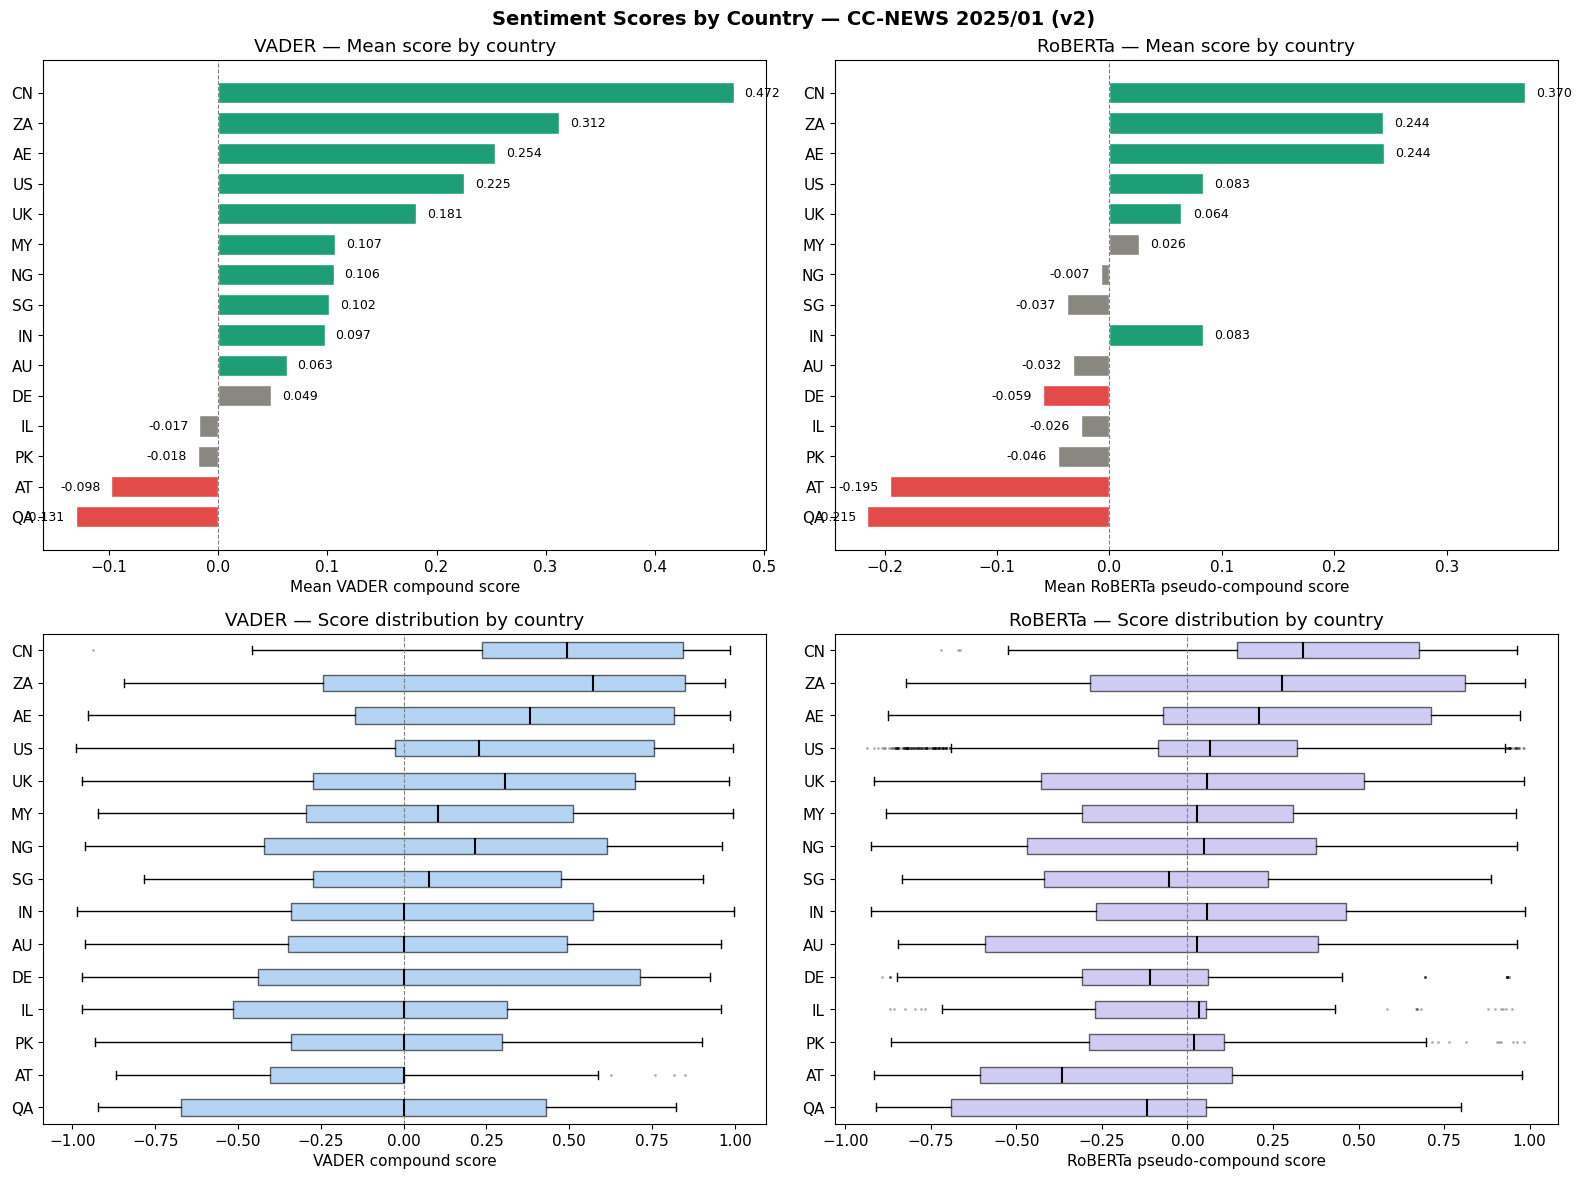

Figure saved to /content/drive/MyDrive/UNI/JLU M.Sc Data Analytics/Semester 3/Spezialisierungmodule/data/processed/sentiment_by_country_2025_01_v2.png


In [12]:
# Sort countries by VADER mean for consistent ordering in all plots
country_order = df_summary.sort_values('vader_mean')['country'].tolist()

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle(f'Sentiment Scores by Country — CC-NEWS {TARGET_YEAR}/{TARGET_MONTH} ({DATA_VERSION})',
             fontsize=14, fontweight='bold')

# --- 1. VADER mean by country (bar chart) ---
ax = axes[0, 0]
vader_means = [df_valid[df_valid['country_url'] == c]['vader_compound'].mean() for c in country_order]
colors = ['#E24B4A' if m < -0.05 else '#1D9E75' if m > 0.05 else '#888780' for m in vader_means]
ax.barh(country_order, vader_means, color=colors, edgecolor='white', height=0.7)
ax.set_xlabel('Mean VADER compound score')
ax.set_title('VADER — Mean score by country')
ax.axvline(x=0, color='gray', linestyle='--', linewidth=0.8)
for i, (c, m) in enumerate(zip(country_order, vader_means)):
    ax.text(m + 0.01 if m >= 0 else m - 0.01, i, f'{m:.3f}',
            va='center', ha='left' if m >= 0 else 'right', fontsize=9)

# --- 2. RoBERTa mean by country (bar chart) ---
ax = axes[0, 1]
roberta_means = [df_valid[df_valid['country_url'] == c]['roberta_compound'].mean() for c in country_order]
colors = ['#E24B4A' if m < -0.05 else '#1D9E75' if m > 0.05 else '#888780' for m in roberta_means]
ax.barh(country_order, roberta_means, color=colors, edgecolor='white', height=0.7)
ax.set_xlabel('Mean RoBERTa pseudo-compound score')
ax.set_title('RoBERTa — Mean score by country')
ax.axvline(x=0, color='gray', linestyle='--', linewidth=0.8)
for i, (c, m) in enumerate(zip(country_order, roberta_means)):
    ax.text(m + 0.01 if m >= 0 else m - 0.01, i, f'{m:.3f}',
            va='center', ha='left' if m >= 0 else 'right', fontsize=9)

# --- 3. VADER boxplot by country ---
ax = axes[1, 0]
vader_data = [df_valid[df_valid['country_url'] == c]['vader_compound'].values for c in country_order]
bp = ax.boxplot(vader_data, vert=False, labels=country_order, patch_artist=True,
                medianprops=dict(color='black', linewidth=1.5),
                flierprops=dict(marker='.', markersize=2, alpha=0.3))
for patch in bp['boxes']:
    patch.set_facecolor('#85B7EB')
    patch.set_alpha(0.6)
ax.set_xlabel('VADER compound score')
ax.set_title('VADER — Score distribution by country')
ax.axvline(x=0, color='gray', linestyle='--', linewidth=0.8)

# --- 4. RoBERTa boxplot by country ---
ax = axes[1, 1]
roberta_data = [df_valid[df_valid['country_url'] == c]['roberta_compound'].values for c in country_order]
bp = ax.boxplot(roberta_data, vert=False, labels=country_order, patch_artist=True,
                medianprops=dict(color='black', linewidth=1.5),
                flierprops=dict(marker='.', markersize=2, alpha=0.3))
for patch in bp['boxes']:
    patch.set_facecolor('#AFA9EC')
    patch.set_alpha(0.6)
ax.set_xlabel('RoBERTa pseudo-compound score')
ax.set_title('RoBERTa — Score distribution by country')
ax.axvline(x=0, color='gray', linestyle='--', linewidth=0.8)

plt.tight_layout()
fig_path = f'{DATA_PROCESSED}/sentiment_by_country_{TARGET_YEAR}_{TARGET_MONTH}_{DATA_VERSION}.png'
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Figure saved to {fig_path}')

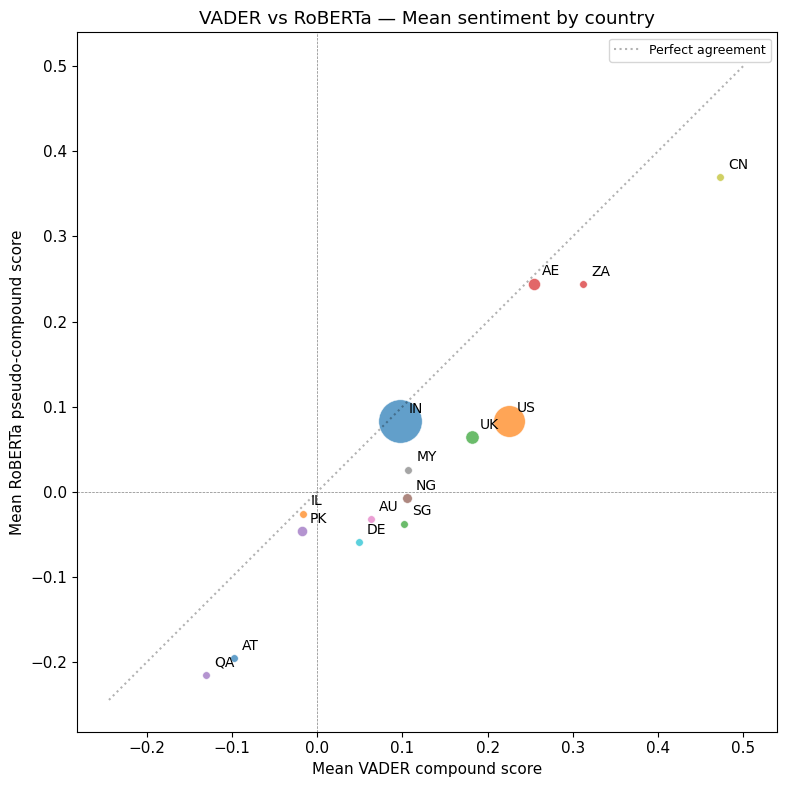

Figure saved to /content/drive/MyDrive/UNI/JLU M.Sc Data Analytics/Semester 3/Spezialisierungmodule/data/processed/vader_vs_roberta_2025_01_v2.png


In [13]:
# --- VADER vs RoBERTa agreement scatter (per country) ---
fig, ax = plt.subplots(figsize=(8, 8))

for country in valid_countries:
    sub = df_valid[df_valid['country_url'] == country]
    vm = sub['vader_compound'].mean()
    rm = sub['roberta_compound'].mean()
    ax.scatter(vm, rm, s=max(len(sub) / 5, 30), alpha=0.7, edgecolors='white', linewidth=0.5)
    ax.annotate(country, (vm, rm), textcoords='offset points', xytext=(6, 6), fontsize=10)

ax.set_xlabel('Mean VADER compound score')
ax.set_ylabel('Mean RoBERTa pseudo-compound score')
ax.set_title('VADER vs RoBERTa — Mean sentiment by country')
ax.axhline(y=0, color='gray', linestyle='--', linewidth=0.5)
ax.axvline(x=0, color='gray', linestyle='--', linewidth=0.5)

# Add diagonal reference line
lims = [min(ax.get_xlim()[0], ax.get_ylim()[0]), max(ax.get_xlim()[1], ax.get_ylim()[1])]
ax.plot(lims, lims, 'k:', alpha=0.3, label='Perfect agreement')
ax.legend(fontsize=9)

plt.tight_layout()
fig_path2 = f'{DATA_PROCESSED}/vader_vs_roberta_{TARGET_YEAR}_{TARGET_MONTH}_{DATA_VERSION}.png'
plt.savefig(fig_path2, dpi=150, bbox_inches='tight')
plt.show()
print(f'Figure saved to {fig_path2}')

---
## 6. Label Distribution by Country

In [14]:
print('VADER label distribution by country:')
print('=' * 55)
print(f'{"Country":>8s} {"n":>6s} {"% neg":>8s} {"% neu":>8s} {"% pos":>8s}')
print('-' * 55)
for country in country_order:
    sub = df_valid[df_valid['country_url'] == country]
    n = len(sub)
    pn = (sub['vader_label'] == 'negative').sum() / n * 100
    pne = (sub['vader_label'] == 'neutral').sum() / n * 100
    pp = (sub['vader_label'] == 'positive').sum() / n * 100
    print(f'{country:>8s} {n:6d} {pn:8.1f} {pne:8.1f} {pp:8.1f}')
print('=' * 55)

print(f'\nRoBERTa label distribution by country:')
print('=' * 55)
print(f'{"Country":>8s} {"n":>6s} {"% neg":>8s} {"% neu":>8s} {"% pos":>8s}')
print('-' * 55)
for country in country_order:
    sub = df_valid[df_valid['country_url'] == country]
    n = len(sub)
    pn = (sub['roberta_label'] == 'negative').sum() / n * 100
    pne = (sub['roberta_label'] == 'neutral').sum() / n * 100
    pp = (sub['roberta_label'] == 'positive').sum() / n * 100
    print(f'{country:>8s} {n:6d} {pn:8.1f} {pne:8.1f} {pp:8.1f}')
print('=' * 55)

VADER label distribution by country:
 Country      n    % neg    % neu    % pos
-------------------------------------------------------
      QA     52     48.1     15.4     36.5
      AT     82     40.2     36.6     23.2
      PK    265     33.2     32.1     34.7
      IL     78     37.2     28.2     34.6
      DE     85     38.8     17.6     43.5
      AU    115     32.2     22.6     45.2
      IN   4903     31.6     19.9     48.5
      SG     61     36.1     11.5     52.5
      NG    240     36.7      7.9     55.4
      MY     89     32.6     13.5     53.9
      UK    458     31.7     10.3     58.1
      US   2598     24.5     19.7     55.8
      AE    374     26.7     17.9     55.3
      ZA     56     26.8      5.4     67.9
      CN     87      8.0     11.5     80.5

RoBERTa label distribution by country:
 Country      n    % neg    % neu    % pos
-------------------------------------------------------
      QA     52     28.8     65.4      5.8
      AT     82     41.5     45.1    

---
## 7. Next Steps

**What this notebook established:**
- Raw sentiment scores for all country-assigned articles
- Preliminary comparison of mean scores across countries
- Statistical test for whether differences are significant

**What this does NOT yet control for:**
- Writing style differences (syntactic covariates — Notebook 04)
- Whether the article was *published in* vs *about* a country (NER — Notebook 03)
- Gold standard accuracy assessment (annotation — Notebook 05)

**Subsequent notebooks:**
- **Notebook 03 — NER + Geonames:** Adds `country_ner` column (Method 2 of 3)
- **Notebook 04 — Syntactic covariates:** Adds word/sentence/paragraph length controls
- **Notebook 05 — Annotation:** Manual gold standard for classifier evaluation
- **Notebook 06 — Regression:** Full hypothesis test with controls

## 7. Data Funnel Summary

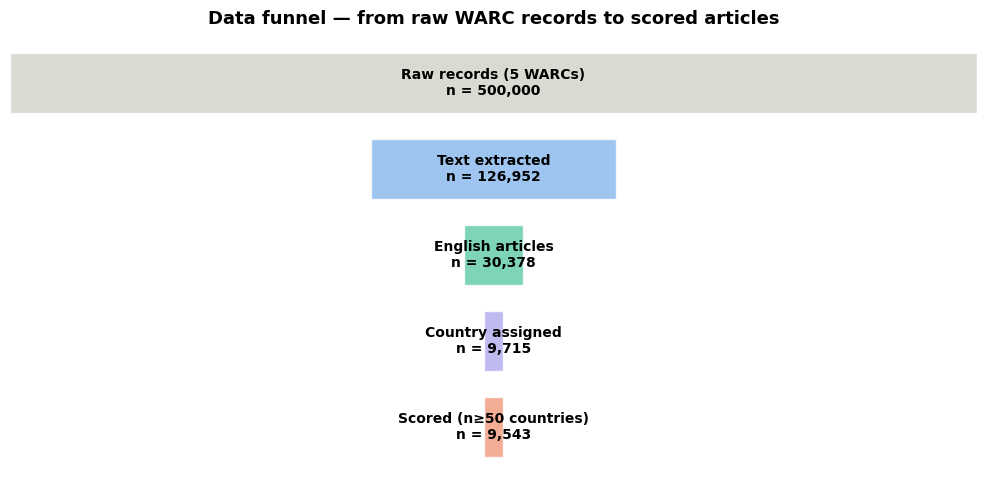

In [15]:
# --- Data funnel: article counts at each pipeline stage ---
stages = [
    ('Raw records (5 WARCs)', 500000, '#D3D1C7'),
    ('Text extracted', 126952, '#85B7EB'),
    ('English articles', 30378, '#5DCAA5'),
    ('Country assigned', 9715, '#AFA9EC'),
    ('Scored (n≥50 countries)', 9543, '#F0997B'),
]

fig, ax = plt.subplots(figsize=(10, 5))
max_val = stages[0][1]

for i, (label, count, color) in enumerate(stages):
    width = count / max_val
    bar_left = (1 - width) / 2
    ax.barh(len(stages) - 1 - i, width, left=bar_left, height=0.7,
            color=color, edgecolor='white', alpha=0.8)
    ax.text(0.5, len(stages) - 1 - i, f'{label}\nn = {count:,}',
            ha='center', va='center', fontsize=10, fontweight='bold')

ax.set_xlim(0, 1)
ax.set_yticks([])
ax.set_xticks([])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.set_title('Data funnel — from raw WARC records to scored articles', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{DATA_PROCESSED}/data_funnel_{DATA_VERSION}.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. VADER Sentiment Distribution by Country (Stacked Bar)

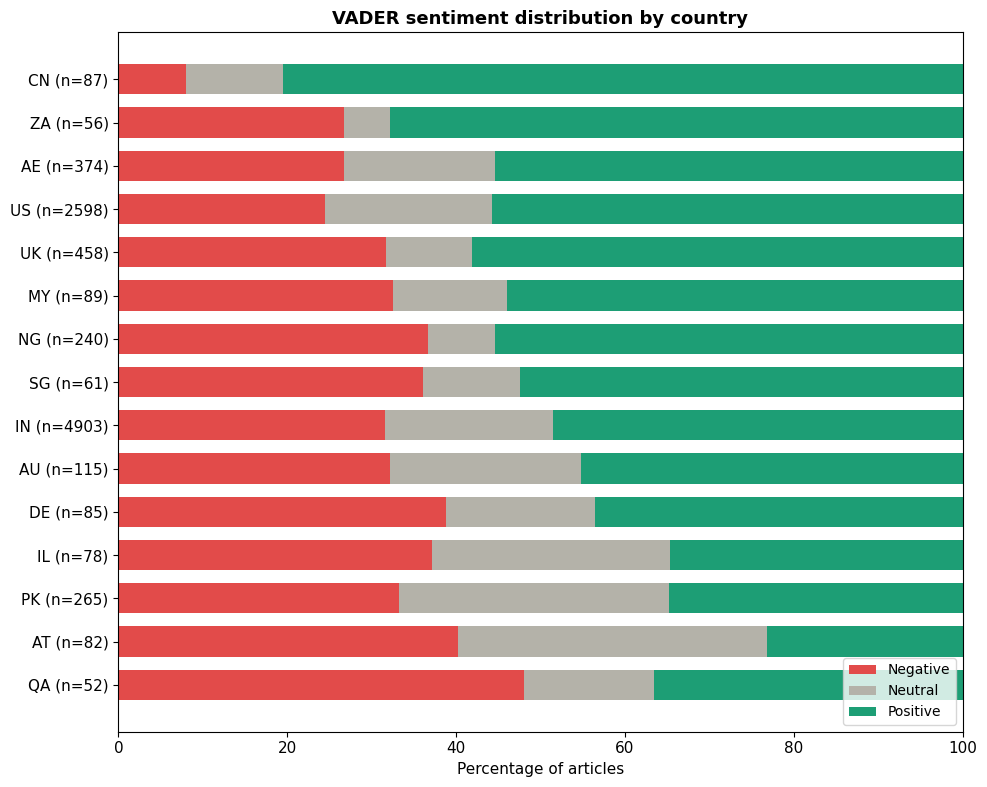

In [16]:
# --- Stacked sentiment distribution by country ---
sent_data = []
for country in country_order:
    sub = df_valid[df_valid['country_url'] == country]
    n = len(sub)
    sent_data.append({
        'country': country,
        'n': n,
        'neg': (sub['vader_label'] == 'negative').sum() / n * 100,
        'neu': (sub['vader_label'] == 'neutral').sum() / n * 100,
        'pos': (sub['vader_label'] == 'positive').sum() / n * 100,
    })

df_sent = pd.DataFrame(sent_data)

fig, ax = plt.subplots(figsize=(10, 8))

y = range(len(df_sent))
ax.barh(y, df_sent['neg'], color='#E24B4A', label='Negative', height=0.7)
ax.barh(y, df_sent['neu'], left=df_sent['neg'], color='#B4B2A9', label='Neutral', height=0.7)
ax.barh(y, df_sent['pos'], left=df_sent['neg'] + df_sent['neu'], color='#1D9E75', label='Positive', height=0.7)

ax.set_yticks(y)
ax.set_yticklabels([f"{r['country']} (n={r['n']})" for _, r in df_sent.iterrows()])
ax.set_xlabel('Percentage of articles')
ax.set_title('VADER sentiment distribution by country', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.set_xlim(0, 100)

plt.tight_layout()
plt.savefig(f'{DATA_PROCESSED}/vader_distribution_by_country_{DATA_VERSION}.png', dpi=150, bbox_inches='tight')
plt.show()